In [42]:
import numpy as np 
import pandas as pd 


In [43]:
df=pd.read_csv('C:\CarPricePrediction\data\car data.csv')
print(df.head())
print(df.shape)
print(df.info())

  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  
(301, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price

# Data Cleaning


In [44]:
print(df.isnull().sum())
print("Duplicates:" ,df.duplicated().sum())


Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64
Duplicates: 2


In [45]:
# Removing Duplicates 
df=df.drop_duplicates()

In [46]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,299.000000,299.000000,299.000000,299.000000,299.000000
mean,2013.615385,4.589632,7.541037,36916.752508,0.043478
std,2.896868,4.984240,8.567887,39015.170352,0.248720
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.850000,1.200000,15000.000000,0.000000
50%,2014.000000,3.510000,6.100000,32000.000000,0.000000
75%,2016.000000,6.000000,9.840000,48883.500000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


# Data Visualisation

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

### Selling Price Distribution 

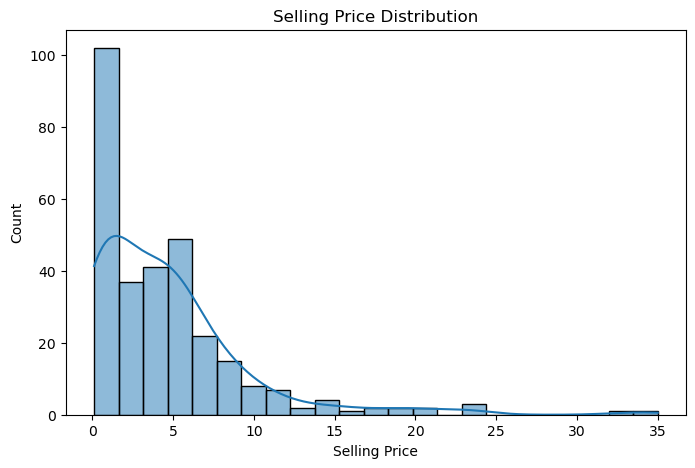

In [48]:
plt.figure(figsize=(8,5))
sns.histplot(df["Selling_Price"],kde=True)
plt.title("Selling Price Distribution")
plt.xlabel("Selling Price")
plt.show()

### Year vs Selling Price Distribution

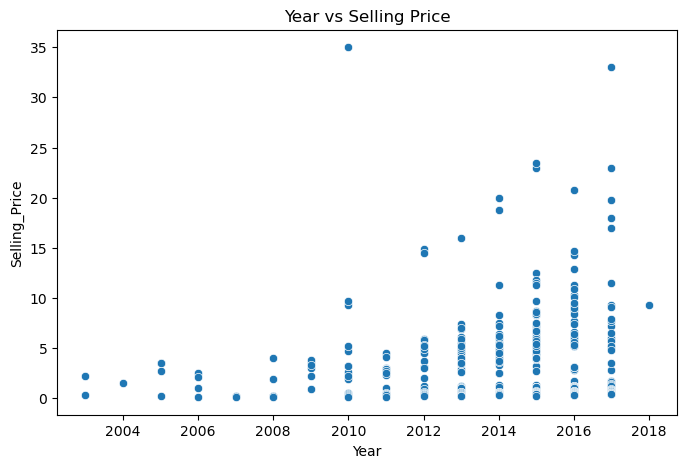

In [49]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Year", y="Selling_Price")
plt.title("Year vs Selling Price")
plt.show()

## Km driven vs Selling Price 


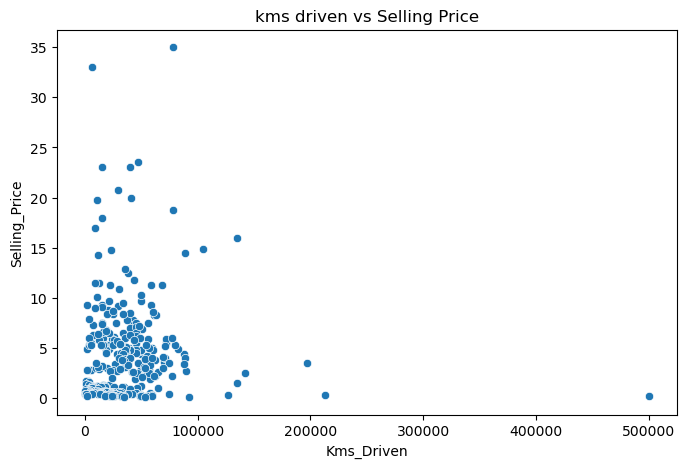

In [50]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x='Kms_Driven', y="Selling_Price")
plt.title("kms driven vs Selling Price")
plt.show()

### BoxPlot

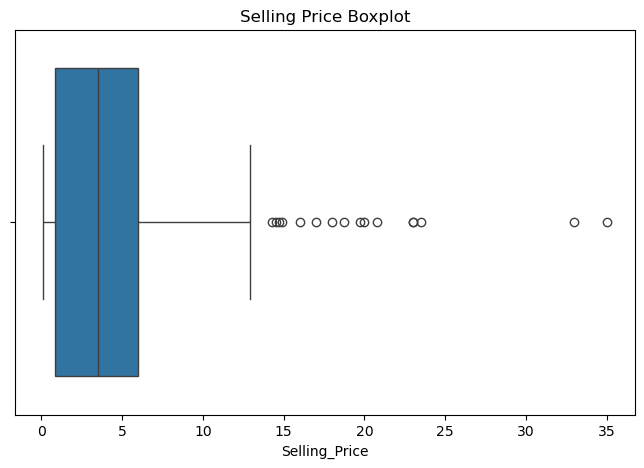

In [51]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Selling_Price"])
plt.title("Selling Price Boxplot")
plt.show()

## Correlation

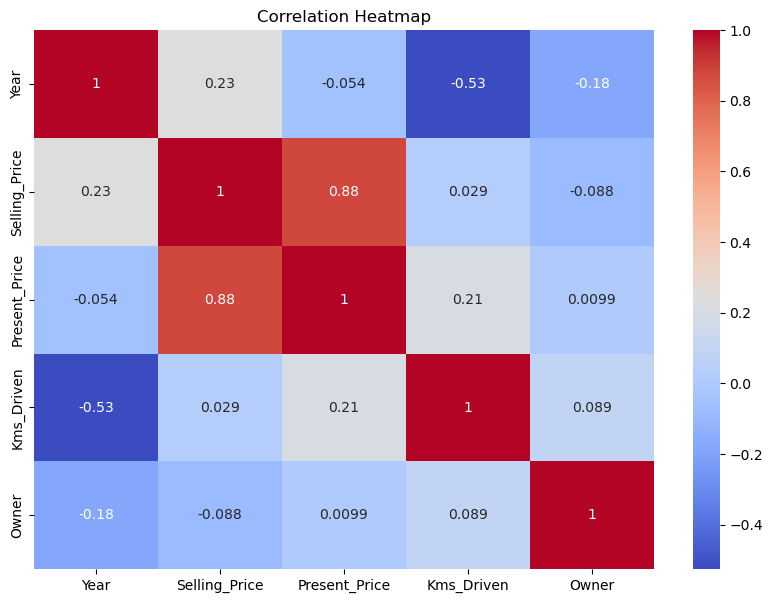

In [52]:
numeric_df= df.select_dtypes(include=np.number)
plt.figure(figsize=(10,7))
sns.heatmap(numeric_df.corr(), annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [53]:
current_year=2026
df['Car_Age'] = current_year -df['Year']
df.drop('Year',axis=1)


,Car_Name,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,4.60,6.87,42450,Diesel,Dealer,Manual,0,12
...,...,...,...,...,...,...,...,...,...
296,city,9.50,11.60,33988,Diesel,Dealer,Manual,0,10
297,brio,4.00,5.90,60000,Petrol,Dealer,Manual,0,11
298,city,3.35,11.00,87934,Petrol,Dealer,Manual,0,17
299,city,11.50,12.50,9000,Diesel,Dealer,Manual,0,9


### Selection of Dependent and Independent Features 

In [54]:
X = df.drop("Selling_Price", axis=1)

y = df["Selling_Price"]

## Train-Test Split 

In [55]:
from sklearn.model_selection import train_test_split 
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)


In [56]:
# Splitting the data into categorical and numerical parts
categorical_cols = [
    "Fuel_Type",
    "Seller_Type",
    "Transmission"
]

numerical_cols = [
    "Present_Price",
    "Kms_Driven",
    "Owner",
    "Car_Age"
]

In [57]:
from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import OneHotEncoder,StandardScaler 
preprocessor = ColumnTransformer(
    transformers=[
        ("num",StandardScaler(),numerical_cols),
        ("cat",OneHotEncoder(handle_unknown="ignore"),categorical_cols)
    ]
)

# Linear Regression

In [58]:
from sklearn.pipeline import Pipeline 
from sklearn.linear_model import LinearRegression
linear_model = Pipeline([
    ("preprocessor",preprocessor),
    ("model",LinearRegression())
])
linear_model.fit(X_train,y_train)
y_pred= linear_model.predict(X_test)

# Ridge Regression

In [59]:
from sklearn.linear_model import Ridge
ridge_model =Pipeline([
    ("preprocessor",preprocessor),
    ("model",Ridge(alpha=1.0))
])
ridge_model.fit(X_train,y_train)
ridge_pred = ridge_model.predict(X_test)


# Lasso Regression

In [60]:
from sklearn.linear_model import Lasso
lasso_model =Pipeline([
    ("preprocessor",preprocessor),
    ("model",Lasso(alpha=0.01))
])
lasso_model.fit(X_train,y_train)
lasso_pred = ridge_model.predict(X_test)


# Elastic Net

In [61]:
from sklearn.linear_model import ElasticNet
elastic_model = Pipeline([
    ("preprocessor",preprocessor),
    ("model",ElasticNet(alpha=0.01,l1_ratio=0.5))

])
elastic_model.fit(X_train,y_train)
elastic_pred=elastic_model.predict(X_test)

# Evaluating Models 

In [62]:
import numpy as np
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
def evaluate_models(name,y_test,y_pred):
    mae= mean_absolute_error(y_test,y_pred)
    mse= mean_squared_error(y_test,y_pred)
    rmse =np.sqrt(mse)
    score= r2_score(y_test,y_pred)
    print(name)
    print("Mean absolute Error" ,mae)
    print("Mean squared Error", mse)
    print("Root mean squared Error", rmse)
    print("r2_score",score)
    print()

In [63]:
evaluate_models("Linear Regression",y_test,y_pred)
evaluate_models("Ridge Regression",y_test,ridge_pred)
evaluate_models("Lasso Regression",y_test,lasso_pred)
evaluate_models("Elastic Net", y_test,elastic_pred)

Linear Regression
Mean absolute Error 1.4728924140032922
Mean squared Error 6.37075295682325
Root mean squared Error 2.5240350545947754
r2_score 0.7528154215832926

Ridge Regression
Mean absolute Error 1.4808062525600998
Mean squared Error 6.3657301969446936
Root mean squared Error 2.523039872246313
r2_score 0.7530103041649095

Lasso Regression
Mean absolute Error 1.4808062525600998
Mean squared Error 6.3657301969446936
Root mean squared Error 2.523039872246313
r2_score 0.7530103041649095

Elastic Net
Mean absolute Error 1.4864088191656237
Mean squared Error 6.35299315549832
Root mean squared Error 2.5205144624656133
r2_score 0.7535045001008587



# Cross Validation Score 

In [64]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(ridge_model,X,y,cv=5,scoring="r2")
print("CV scores:", scores)
print("Mean CV R2",scores.mean())

CV scores: [   0.87326855    0.77903654 -105.3810587     0.59708991    0.82753137]
Mean CV R2 -20.460826465911936


# Selecting the best model

In [66]:
final_model= ridge_model
final_model.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [72]:
import joblib 
joblib.dump(final_model ,"models/car_price_pickle.pkl")

['models/car_price_pickle.pkl']